In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv('IPIP300-SCORES.csv')  # adjust filename to match your download
df.head()

print(df.columns.tolist())

['case', 'sex', 'age', 'sec', 'min', 'hour', 'date', 'month', 'year', 'country', 'i1', 'i2', 'i3', 'i4', 'i5', 'i6', 'i7', 'i8', 'i9', 'i10', 'i11', 'i12', 'i13', 'i14', 'i15', 'i16', 'i17', 'i18', 'i19', 'i20', 'i21', 'i22', 'i23', 'i24', 'i25', 'i26', 'i27', 'i28', 'i29', 'i30', 'i31', 'i32', 'i33', 'i34', 'i35', 'i36', 'i37', 'i38', 'i39', 'i40', 'i41', 'i42', 'i43', 'i44', 'i45', 'i46', 'i47', 'i48', 'i49', 'i50', 'i51', 'i52', 'i53', 'i54', 'i55', 'i56', 'i57', 'i58', 'i59', 'i60', 'i61', 'i62', 'i63', 'i64', 'i65', 'i66', 'i67', 'i68', 'i69', 'i70', 'i71', 'i72', 'i73', 'i74', 'i75', 'i76', 'i77', 'i78', 'i79', 'i80', 'i81', 'i82', 'i83', 'i84', 'i85', 'i86', 'i87', 'i88', 'i89', 'i90', 'i91', 'i92', 'i93', 'i94', 'i95', 'i96', 'i97', 'i98', 'i99', 'i100', 'i101', 'i102', 'i103', 'i104', 'i105', 'i106', 'i107', 'i108', 'i109', 'i110', 'i111', 'i112', 'i113', 'i114', 'i115', 'i116', 'i117', 'i118', 'i119', 'i120', 'i121', 'i122', 'i123', 'i124', 'i125', 'i126', 'i127', 'i128', 'i1

In [7]:
# Keep only Big Five scores

ocean_cols = [
    'openness',
    'conscientiousness',
    'extraversion',
    'agreeableness',
    'neuroticism'
]

df_ocean = df[ocean_cols].dropna()

scaler = StandardScaler()


In [8]:
train_df, test_df = train_test_split(df_ocean, test_size=0.2, random_state=42)


In [9]:
# stanrdardize features on test and training sets
x_train = scaler.fit_transform(train_df)
x_test = scaler.transform(test_df)


In [10]:
train_df.head()


,openness,conscientiousness,extraversion,agreeableness,neuroticism
103072,39.839018,79.681584,40.994750,89.220154,88.660582
88157,5.685767,6.966800,39.737516,42.569498,49.516462
111026,36.247287,56.569103,1.000000,45.053533,73.254047
75742,35.197096,64.499078,97.885254,82.226654,1.000000
103410,36.475352,52.200734,2.989544,61.225275,84.019631


In [11]:
train_df.describe()

,openness,conscientiousness,extraversion,agreeableness,neuroticism
count,116310.000000,116310.000000,116310.000000,116310.000000,116310.000000
mean,48.193519,49.853481,53.960321,52.926907,51.111668
std,28.305265,29.179161,28.595707,27.987164,28.960041
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,24.914390,25.259856,31.122227,31.338346,27.075921
50%,48.127295,50.574003,56.494957,55.196235,50.483538
75%,71.521857,74.127552,78.003665,76.160555,75.446499
max,99.674629,99.674671,99.674388,99.674793,99.674578


In [12]:
test_df.describe()

,openness,conscientiousness,extraversion,agreeableness,neuroticism
count,29078.000000,29078.000000,29078.000000,29078.000000,29078.000000
mean,48.273099,49.864349,53.818711,52.592464,51.273951
std,28.353954,29.028082,28.672138,28.227697,29.095353
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,24.914390,26.200877,31.122227,31.137573,27.104893
50%,48.127295,50.574003,56.188309,54.167234,50.483538
75%,71.551883,73.779808,77.730415,76.160555,75.690130
max,99.674629,99.674671,99.674388,99.674793,99.674578


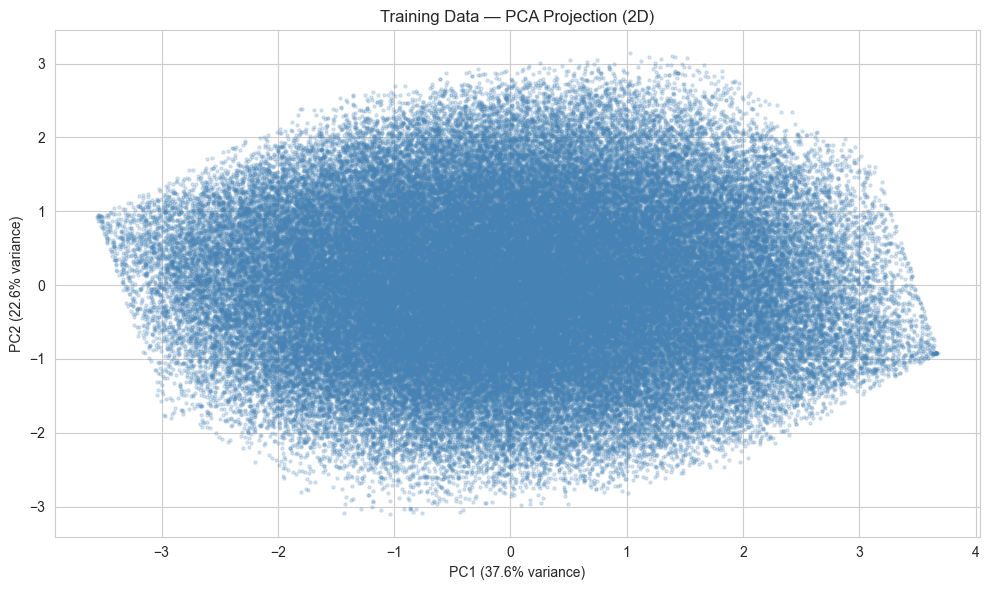

In [13]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(x_train)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            s=5,          # slightly bigger points
            alpha=0.2,    # more transparent to show density
            color='steelblue')

plt.title('Training Data — PCA Projection (2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.savefig('visual_train_data.png', dpi=150)
plt.show()

In [14]:
# define K-means function
def kmeans(X, k, max_iters=300, tol=1e-4, random_state=42):
    # create a random number generator to make reproducible results
    rand_numb = np.random.default_rng(random_state)

    # pick first centroid
    # randomly genereate an integer between 0 and length of the dataset (n-1)
    first_index = rand_numb.integers(0, len(X))
    centroids = [X[first_index]] # start centroid list with randomly generated integer

    # for loop until we have k centroids
    for _ in range(k - 1):
        # compute the squared distance to the nearest centroid for each point
        # take minimum distance for every point from centroid c
        dists = np.array([
            min(np.sum((x - c) ** 2) for c in centroids)
            for x in X
        ])

        # convert distances to be probabilities
        probs = dists / dists.sum()

        # determine the next centroid
        # draw a random number and find its position through a cumulative sum of the
        # probailities created
        next_index = np.searchsorted(np.cumsum(probs), rand_numb.random())

        # add that point to list of centroids
        centroids.append(X[next_index])

    # convert list of centroids into a numpy array
    centroids = np.array(centroids)

    # create an array of labels that will track which cluster each point belongs to
    labels = np.zeros(len(X), dtype=int) # start with zero array

    # loop up to the max number of iterations set by parameter
    for iteration in range(max_iters):
        # compute the difference between every point and every centroid
        diffs = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]

        # square the differences calculated and sum them (squared Euclidean distance)
        dists = np.sum(diffs ** 2, axis=2)

        # for each point, find the index of the smallest distance
        # this index is the cluster ID for that point
        new_labels = np.argmin(dists, axis=1)

        # recalculate the centroids so that it is the mean of the
        # points that were assigned to it
        new_centroids = np.array([
            X[new_labels == j].mean(axis=0)
            if np.any(new_labels == j)
            else centroids[j]
            for j in range(k)
                                 ])

        # measure how far each centroid moved from the previous iteration

        # subtract old centroid from new centroid to get the distance it moved
        # calculated by squaring the sum across centroid coordinates and taking its square root
        # get the max of these centroid movements across all k centroids
        shift = np.sqrt(np.sum((new_centroids - centroids) ** 2, axis=1)).max()

        # update labels and centroids for next iteration
        labels = new_labels
        centroids = new_centroids

        # if the centroid movement is less than the tol, then the algorithm has converged
        # the iterative process of updating clusters reached stability
        if shift < tol:
            print(f" K-Means converged at iteration {iteration + 1}")
            break

    # case for when we hit the max number of iterations established
    else:
        print(f" K-Means hit max_iters ({max_iters})")

    # compute inertia, which is the total sum of squared distances from each point to its centroid
    inertia = sum(
        np.sum((X[labels == j] - centroids[j]) ** 2)
        for j in range(k)
    )

    # return the labels, centroids, and inertia
    return labels, centroids, inertia


In [15]:
# USED LATER FOR TESTING SET
# define function kmeans_predict which assigns each point in X to the nearest centroid
def kmeans_predict(X, centroids):
    # compute difference between each test point and each centroid
    diffs = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]

    # square the differences calculated and sum them
    dists = np.sum(diffs ** 2, axis=2)

    # for each test point return the cluster ID
    return np.argmin(dists, axis=1)


 K-Means converged at iteration 17
 K-Means converged at iteration 102
 K-Means converged at iteration 220
 K-Means converged at iteration 158
 K-Means converged at iteration 120
 K-Means converged at iteration 81
 K-Means converged at iteration 257
 K-Means converged at iteration 89
 K-Means converged at iteration 122
 K-Means converged at iteration 223
 K-Means converged at iteration 86
 K-Means converged at iteration 134
 K-Means converged at iteration 120


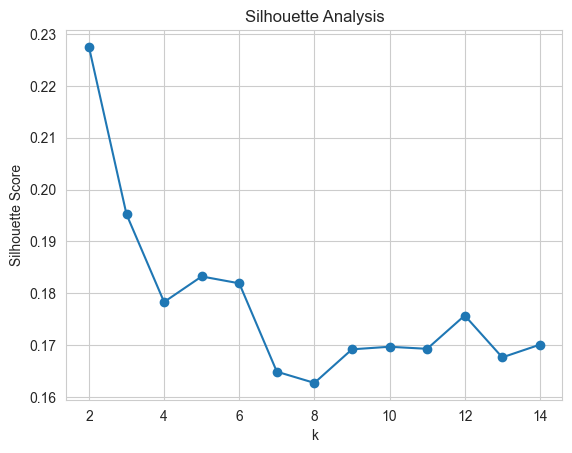

In [16]:
sil_scores = []

for k in range(2, 15):
    labels, centroids, inertia = kmeans(
        x_train,
        k=k,
        random_state=42
    )

    sil = silhouette_score(x_train, labels)

    sil_scores.append(sil)

plt.plot(range(2,15), sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [21]:
centroids_original = scaler.inverse_transform(
    km_centroids
)

cluster_profiles = pd.DataFrame(
    centroids_original,
    columns=ocean_cols
)

cluster_profiles.index = [
    "Cluster 0",
    "Cluster 1",
    "Cluster 2",
    "Cluster 3",
    "Cluster 4",
    "Cluster 5"
]

cluster_profiles.round(2)

,openness,conscientiousness,extraversion,agreeableness,neuroticism
Cluster 0,29.29,60.24,67.23,31.24,34.21
Cluster 1,28.63,26.53,26.64,29.09,80.37
Cluster 2,69.61,35.00,31.82,70.61,73.34
Cluster 3,23.94,68.44,39.10,71.81,48.08
Cluster 4,65.66,72.88,77.64,74.55,23.06
Cluster 5,70.91,26.71,73.65,34.61,57.96


In [17]:
# have K = 6
K = 6

print(f"\nTraining K-Means with k={K}...")

# run our kmeans algorithm with the chosen k and training data
km_labels, km_centroids, km_inertia = kmeans(x_train, k=K, random_state=42)


Training K-Means with k=6...
 K-Means converged at iteration 120


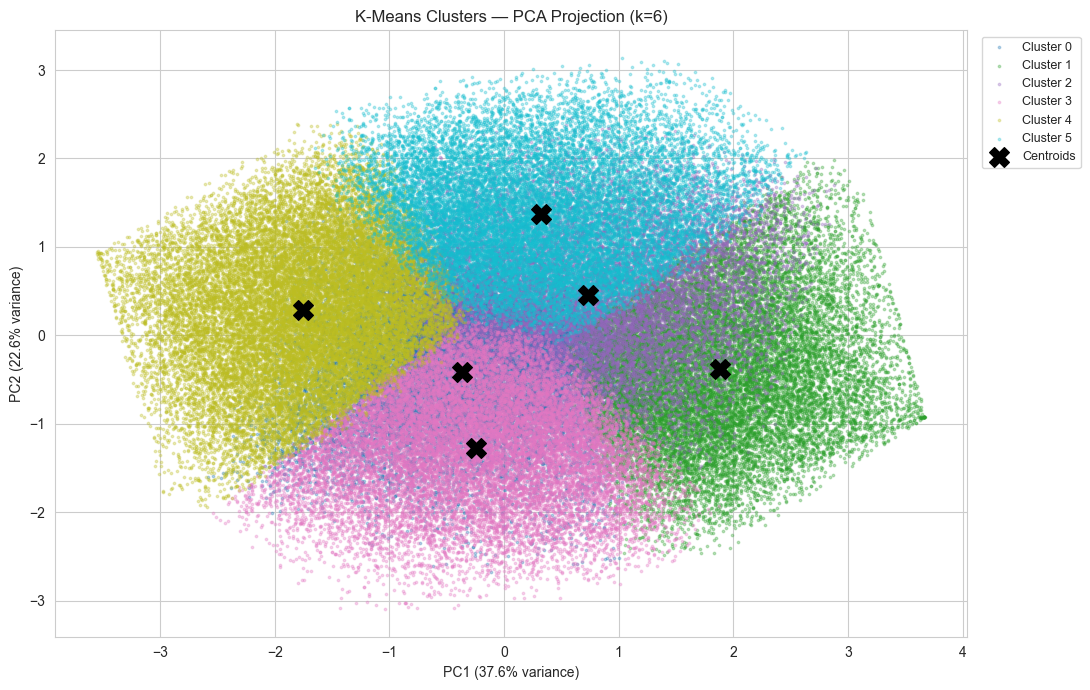

In [18]:
# project to 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(x_train)

# Project centroids to same PCA space
centroids_pca = pca.transform(km_centroids)

colors = plt.cm.tab10(np.linspace(0, 1, K))

plt.figure(figsize=(11, 7))

for j in range(K):
    mask = km_labels == j
    plt.scatter(X_train_pca[mask, 0],
                X_train_pca[mask, 1],
                s=3, color=colors[j],
                alpha=0.3, label=f"Cluster {j}")

# Plot centroids
plt.scatter(centroids_pca[:, 0],
            centroids_pca[:, 1],
            s=200, c='black',
            marker='X', zorder=5,
            label='Centroids')

plt.title(f'K-Means Clusters — PCA Projection (k={K})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(markerscale=1, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('kmeans_train.png', dpi=150)
plt.show()

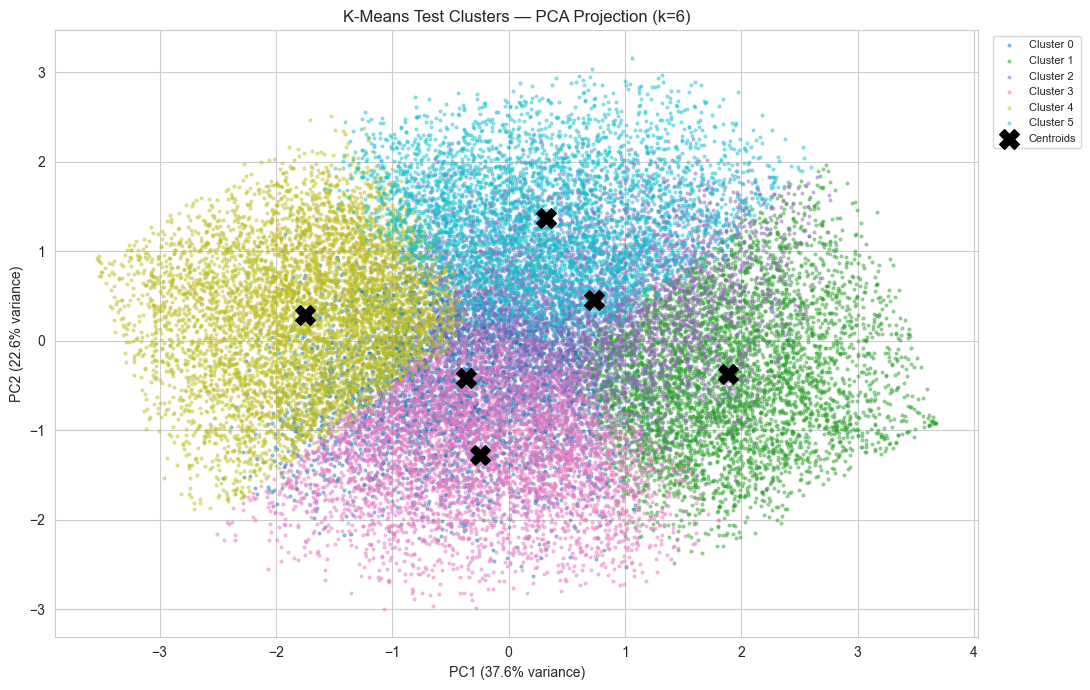

In [19]:
# use trained centroids to predict cluster label for test dataset
km_test_labels = kmeans_predict(x_test, km_centroids)

# project test data to same PCA space (use the pca object already fitted on training data)
X_test_pca = pca.transform(x_test)
centroids_pca = pca.transform(km_centroids)

# visualize test clusters
plt.figure(figsize=(11, 7))

# plot each cluster
for j in range(K):
    mask = km_test_labels == j
    plt.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                s=4, color=colors[j], alpha=0.4, label=f"Cluster {j}")

# plot centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=200, c='black', marker='X', zorder=5, label='Centroids')

plt.title(f'K-Means Test Clusters — PCA Projection (k={K})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(markerscale=1, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('kmeans_test.png', dpi=150)
plt.show()

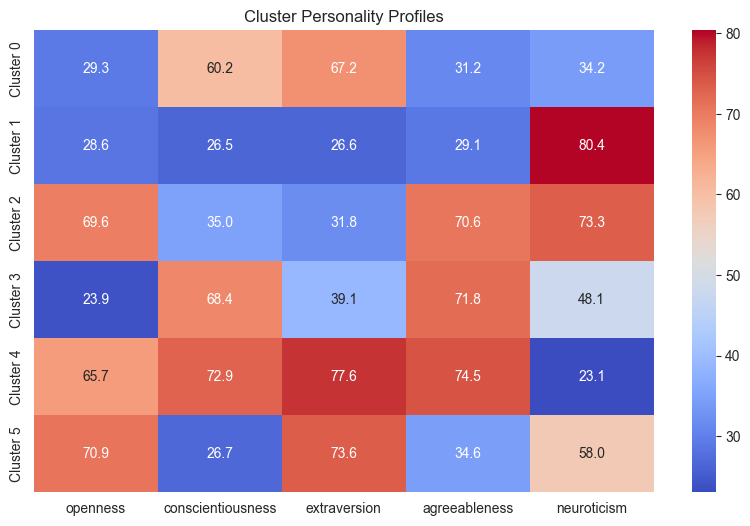

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profiles,
    annot=True,
    cmap='coolwarm',
    fmt='.1f'
)

plt.title('Cluster Personality Profiles')
plt.show()

OPTIMIZATION BASED TEAM ASSIGNMENT

In [23]:
# Attach cluster labels to the original training data
train_clusters = train_df.copy()
train_clusters["cluster"] = km_labels

# Add a student ID so we can track assignments
train_clusters = train_clusters.reset_index(drop=True)
train_clusters["student_id"] = train_clusters.index

train_clusters.head()

,openness,conscientiousness,extraversion,agreeableness,neuroticism,cluster,student_id
0,39.839018,79.681584,40.994750,89.220154,88.660582,3,0
1,5.685767,6.966800,39.737516,42.569498,49.516462,1,1
2,36.247287,56.569103,1.000000,45.053533,73.254047,1,2
3,35.197096,64.499078,97.885254,82.226654,1.000000,4,3
4,36.475352,52.200734,2.989544,61.225275,84.019631,1,4


In [24]:
# Check how many students are in each cluster
train_clusters["cluster"].value_counts().sort_index()

cluster
0    18197
1    19407
2    16431
3    19445
4    24639
5    18191
Name: count, dtype: int64

In [25]:
# Team Assignment Algorithm

TEAM_SIZE = 4
RANDOM_STATE = 42

# Shuffle the students so team assignments are not based on original row order
students = train_clusters.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Separate students by cluster
cluster_groups = {
    c: students[students["cluster"] == c].reset_index(drop=True)
    for c in range(K)
}

teams = []
team_id = 0

# Keep creating teams while we still have enough students
while sum(len(group) for group in cluster_groups.values()) >= TEAM_SIZE:
    team_members = []

    # Pick from the largest remaining clusters first
    cluster_order = sorted(
        cluster_groups.keys(),
        key=lambda c: len(cluster_groups[c]),
        reverse=True
    )

    for c in cluster_order:
        if len(team_members) < TEAM_SIZE and len(cluster_groups[c]) > 0:
            student = cluster_groups[c].iloc[0]
            team_members.append(student)

            # Remove selected student
            cluster_groups[c] = cluster_groups[c].iloc[1:].reset_index(drop=True)

    team = pd.DataFrame(team_members)
    team["team_id"] = team_id
    teams.append(team)

    team_id += 1

cluster_teams = pd.concat(teams, ignore_index=True)

cluster_teams.head()

,openness,conscientiousness,extraversion,agreeableness,neuroticism,cluster,student_id,team_id
0,81.838607,73.096975,96.799526,63.155800,11.748255,4.0,63029.0,0
1,6.345563,94.593570,59.821672,55.196235,50.483538,3.0,30181.0,0
2,13.366619,1.000000,54.679509,1.840692,95.174038,1.0,69223.0,0
3,34.960645,59.991715,68.764787,34.835792,70.751905,0.0,81813.0,0
4,70.325804,29.422284,72.857221,81.762790,29.586299,4.0,1641.0,1


In [26]:
# Check the first few teams

cluster_teams[
    ["team_id", "student_id", "cluster"] + ocean_cols
    ].head(20)

,team_id,student_id,cluster,openness,conscientiousness,extraversion,agreeableness,neuroticism
0,0,63029.0,4.0,81.838607,73.096975,96.799526,63.155800,11.748255
1,0,30181.0,3.0,6.345563,94.593570,59.821672,55.196235,50.483538
2,0,69223.0,1.0,13.366619,1.000000,54.679509,1.840692,95.174038
3,0,81813.0,0.0,34.960645,59.991715,68.764787,34.835792,70.751905
4,1,1641.0,4.0,70.325804,29.422284,72.857221,81.762790,29.586299
5,1,59708.0,3.0,42.982829,56.314344,62.017904,53.794735,67.547330
6,1,60870.0,1.0,46.417319,12.514283,15.650471,56.586832,89.878380
7,1,95200.0,0.0,37.247260,43.700955,89.428502,18.554539,54.738771
8,2,36037.0,4.0,99.646360,90.783677,81.396076,74.088133,49.264336
9,2,38543.0,3.0,58.330891,85.043765,26.559570,85.889470,46.207136


In [27]:
# Random Team Assignment Baseline

random_teams = train_clusters.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

random_teams["team_id"] = random_teams.index // TEAM_SIZE

random_teams.head()

,openness,conscientiousness,extraversion,agreeableness,neuroticism,cluster,student_id,team_id
0,88.507832,4.643369,76.546597,85.413147,29.747259,5,42740,0
1,13.366619,1.000000,54.679509,1.840692,95.174038,1,69223,0
2,81.838607,73.096975,96.799526,63.155800,11.748255,4,63029,0
3,46.417319,12.514283,15.650471,56.586832,89.878380,1,60870,0
4,98.177852,7.486879,54.679509,97.544614,39.225321,2,108447,1


In [28]:
# Team Diversity Evaluation

def average_team_diversity(team_df, ocean_cols):
    diversity_scores = []

    for team_id, team in team_df.groupby("team_id"):
        if len(team) == TEAM_SIZE:
            diversity = team[ocean_cols].var().mean()
            diversity_scores.append(diversity)

    return np.mean(diversity_scores)


cluster_diversity = average_team_diversity(cluster_teams, ocean_cols)
random_diversity = average_team_diversity(random_teams, ocean_cols)

print("Cluster-Based Team Diversity:", round(cluster_diversity, 3))
print("Random Team Diversity:", round(random_diversity, 3))

Cluster-Based Team Diversity: 907.081
Random Team Diversity: 819.398


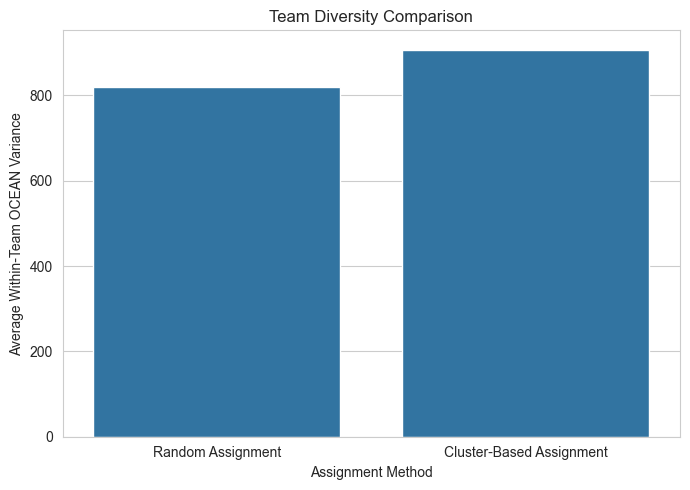

,Method,Average Team Diversity
0,Random Assignment,819.397884
1,Cluster-Based Assignment,907.080708


In [29]:
# Compare Team Assignment Methods

team_results = pd.DataFrame({
    "Method": ["Random Assignment", "Cluster-Based Assignment"],
    "Average Team Diversity": [random_diversity, cluster_diversity]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=team_results,
    x="Method",
    y="Average Team Diversity"
)

plt.title("Team Diversity Comparison")
plt.ylabel("Average Within-Team OCEAN Variance")
plt.xlabel("Assignment Method")

plt.tight_layout()
plt.show()

team_results